In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import warnings

warnings.filterwarnings("ignore")
rng = np.random.default_rng(5141)

n_treated = 40
n_control = 60
TRUE_ATT = 5.0

rows = []
for i in range(n_treated):
    sid = f"T{i}"
    alpha = rng.normal(12, 2)
    for year, post in [(2023, 0), (2024, 1)]:
        delta_year = 1.5 if post else 0.0
        treat_effect = TRUE_ATT if post else 0.0
        eps = rng.normal(0, 1.2)
        Y = alpha + delta_year + treat_effect + eps
        rows.append({"store_id": sid, "year": year, "treated": 1, "post": post, "Y": Y})

for j in range(n_control):
    sid = f"C{j}"
    alpha = rng.normal(10, 2)
    for year, post in [(2023, 0), (2024, 1)]:
        delta_year = 1.5 if post else 0.0
        eps = rng.normal(0, 1.2)
        Y = alpha + delta_year + eps
        rows.append({"store_id": sid, "year": year, "treated": 0, "post": post, "Y": Y})

df_did = pd.DataFrame(rows)
print("Simulated store-year panel (2 periods)")
print(f"True ATT on treated in post: +{TRUE_ATT}")
print(df_did.head(8))

Simulated store-year panel (2 periods)
True ATT on treated in post: +5.0
  store_id  year  treated  post          Y
0       T0  2023        1     0   9.473839
1       T0  2024        1     1  14.539162
2       T1  2023        1     0  12.093955
3       T1  2024        1     1  18.199726
4       T2  2023        1     0  15.489879
5       T2  2024        1     1  22.466538
6       T3  2023        1     0  11.032999
7       T3  2024        1     1  17.111704


Cell means (treated/control x pre/post):
post             0          1
treated                      
0         9.533784  11.009528
1        11.617076  18.572213
Manual DID = (T post - T pre) - (C post - C pre) = 5.4794
Saturated regression coefficients:
const           9.533784
treated         2.083291
post            1.475744
treated_post    5.479394
dtype: float64
Interaction coefficient (treated*post): 5.4794
Difference vs manual DID: 0.000000


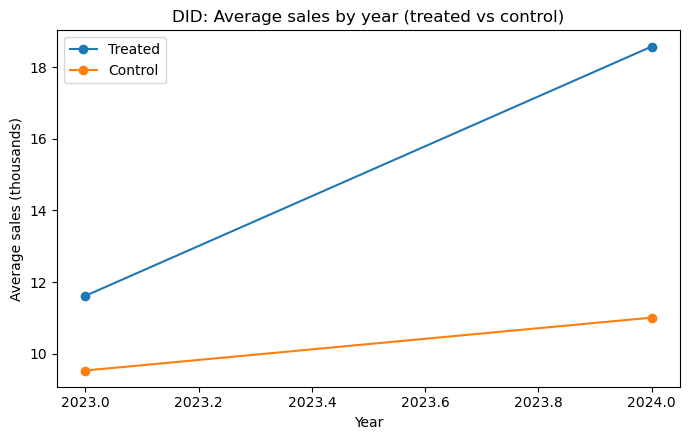

In [2]:
# 1) Four cell means + manual DID
cell_means = (
    df_did.groupby(["treated", "post"])["Y"].mean().unstack("post")
)

Y_T_pre = df_did.query("treated==1 and post==0")["Y"].mean()
Y_T_post = df_did.query("treated==1 and post==1")["Y"].mean()
Y_C_pre = df_did.query("treated==0 and post==0")["Y"].mean()
Y_C_post = df_did.query("treated==0 and post==1")["Y"].mean()

manual_did = (Y_T_post - Y_T_pre) - (Y_C_post - Y_C_pre)

print("Cell means (treated/control x pre/post):")
print(cell_means)
print(f"Manual DID = (T post - T pre) - (C post - C pre) = {manual_did:.4f}")

# 2) Saturated regression: Y ~ treated + post + treated*post
X = pd.DataFrame({
    "treated": df_did["treated"],
    "post": df_did["post"],
    "treated_post": df_did["treated"] * df_did["post"],
})
X = sm.add_constant(X)
model = sm.OLS(df_did["Y"], X).fit()

beta = model.params
print("Saturated regression coefficients:")
print(beta)
print(f"Interaction coefficient (treated*post): {beta['treated_post']:.4f}")
print(f"Difference vs manual DID: {beta['treated_post'] - manual_did:.6f}")

# 3) Plot mean Y by year for treated vs control
plot_means = df_did.groupby(["year", "treated"], as_index=False)["Y"].mean()

plt.figure(figsize=(7, 4.5))
for tval, label in [(1, "Treated"), (0, "Control")]:
    tmp = plot_means[plot_means["treated"] == tval].sort_values("year")
    plt.plot(tmp["year"], tmp["Y"], marker="o", label=label)

plt.xlabel("Year")
plt.ylabel("Average sales (thousands)")
plt.title("DID: Average sales by year (treated vs control)")
plt.legend()
plt.tight_layout()
plt.show()



In the plot, treated and control series should move similarly in the pre period; a violation would look like a divergence even before the policy starts.
With only one pre and one post period, you cannot test parallel trends statistically because there is no time series of pre outcomes to estimate a trend.